**Title: Student Exam Performance**

In [1]:
# Step 01: Importing Libraries

# Student Exam Score Prediction Using ANN

This project is based on Artificial Neural Networks (ANN) using PyTorch.

The main objective of this project is to predict student exam scores based on different factors such as:
- Study Hours
- Sleep Hours
- Attendance Percentage
- Previous Scores

The project follows the complete Deep Learning workflow including:
- Data Preprocessing
- Feature Selection
- Data Normalization
- Train-Test Split
- Tensor Conversion
- Dataset & DataLoader Creation
- ANN Model Building
- Forward Propagation
- Backpropagation
- Loss Calculation
- Model Training
- Evaluation
- Prediction
- Model Saving

Technologies Used:
- Python
- PyTorch
- Pandas
- NumPy
- Scikit-learn
- Matplotlib

Model Architecture:
Input Layer → Hidden Layer → Hidden Layer → Output Layer

This project helped in understanding:
- Neural Networks
- Tensors
- Loss Functions
- Optimizers
- Training Loop
- Forward & Backward Propagation
- Deep Learning Workflow

Future Improvements:
- Build Web Application
- Add Real-Time Prediction
- Improve Model Accuracy
- Deploy Model Using Flask/FastAPI
- Add Visualization Dashboard

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim

In [3]:
# step 02: Uploading Data

In [4]:
df = pd.read_csv('student_exam_scores.csv')

In [8]:
# step 03 : Checking dataset

In [9]:
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [10]:
df

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


In [15]:
df.shape

(200, 6)

In [16]:
df.tail()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0
199,S200,10.2,6.3,97.4,68,37.8


In [17]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [19]:
# Step 04: Handle Missing values

In [20]:
df.isnull().sum()

,0
student_id,0
hours_studied,0
sleep_hours,0
attendance_percent,0
previous_scores,0
exam_score,0


In [23]:
df = df.dropna()
# it remove the rows that contain null values

In [24]:
df.shape

(200, 6)

In [25]:
# Step 05: Feature Selection

In [26]:
X = df[['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']]

In [27]:
y = df['exam_score']

In [28]:
X

,hours_studied,sleep_hours,attendance_percent,previous_scores
0,8.0,8.8,72.1,45
1,1.3,8.6,60.7,55
2,4.0,8.2,73.7,86
3,3.5,4.8,95.1,66
4,9.1,6.4,89.8,71
...,...,...,...,...
195,10.5,5.4,94.0,87
196,7.1,6.1,85.1,92
197,1.6,6.9,63.8,76
198,12.0,7.3,50.5,58


In [29]:
y

,exam_score
0,30.2
1,25.0
2,35.8
3,34.0
4,40.3
...,...
195,42.7
196,40.4
197,28.2
198,42.0


In [30]:
# In this step we had choosed the feature which we have to select for the next procedure

In [32]:
# step 6: Encode Categorical Data

In [33]:
# step 07: Normalize data

In [34]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [35]:
# Step 08: Split into train test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
# Step 09: Convert to tensor

In [38]:
x_train = torch.tensor(X_train, dtype=torch.float32)
x_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.float32)
y_test = torch.tensor(y_test.values, dtype=torch.float32)

In [39]:
# step 10: Convert dataset & data loader

In [40]:
class StudentDataset(Dataset):

    def __init__(self, X, y):

        self.X = X
        self.y = y

    def __len__(self):

        return len(self.X)

    def __getitem__(self, index):

        return self.X[index], self.y[index]


train_dataset = StudentDataset(X_train, y_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

In [41]:
# step 11: Builidng an ANN model

In [53]:
class ANNModel(nn.Module):

    def __init__(self):
        super(ANNModel, self).__init__()

        self.fc1 = nn.Linear(4, 16)
        self.relu1 = nn.ReLU()

        self.fc2 = nn.Linear(16, 8)
        self.relu2 = nn.ReLU()

        self.fc3 = nn.Linear(8, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)

        x = self.fc2(x)
        x = self.relu2(x)

        x = self.fc3(x)

        return x


model = ANNModel()

In [54]:
print(inputs.dtype)
print(inputs.shape)

torch.float64
torch.Size([16, 4])


In [55]:
# step 12: Loss function

In [56]:
criterion = nn.MSELoss()

In [57]:
# step 13: Define Optimizer

In [58]:
# using adam optimizer (momentum + smart learning)

In [59]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [60]:
# step 14: Training Loop

In [62]:
epochs = 100

losses = []

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for inputs, targets in train_loader:

        # CONVERT INTO FLOAT
        inputs = inputs.float()
        targets = targets.float()

        outputs = model(inputs)

        loss = criterion(outputs, targets)

        optimizer.zero_grad()

        loss.backward()


        optimizer.step()

        epoch_loss += loss.item()

    losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [1/100] Loss: 11920.6132
Epoch [2/100] Loss: 11474.3099
Epoch [3/100] Loss: 10388.5301
Epoch [4/100] Loss: 8212.7047
Epoch [5/100] Loss: 4961.2505
Epoch [6/100] Loss: 2047.1550
Epoch [7/100] Loss: 1165.5237
Epoch [8/100] Loss: 776.5866
Epoch [9/100] Loss: 640.4751
Epoch [10/100] Loss: 618.0747
Epoch [11/100] Loss: 580.8239
Epoch [12/100] Loss: 568.9139
Epoch [13/100] Loss: 557.8682
Epoch [14/100] Loss: 535.1236
Epoch [15/100] Loss: 543.2380
Epoch [16/100] Loss: 518.7041
Epoch [17/100] Loss: 517.1754
Epoch [18/100] Loss: 508.8537
Epoch [19/100] Loss: 500.4484
Epoch [20/100] Loss: 508.9238
Epoch [21/100] Loss: 494.1472
Epoch [22/100] Loss: 495.4518
Epoch [23/100] Loss: 483.4086
Epoch [24/100] Loss: 486.0564
Epoch [25/100] Loss: 476.6511
Epoch [26/100] Loss: 477.5127
Epoch [27/100] Loss: 477.5761
Epoch [28/100] Loss: 475.5857
Epoch [29/100] Loss: 476.1111
Epoch [30/100] Loss: 464.2311
Epoch [31/100] Loss: 463.8590
Epoch [32/100] Loss: 464.1839
Epoch [33/100] Loss: 466.4451
Epoch [34

In [63]:
# step 15 : Plot loss graph

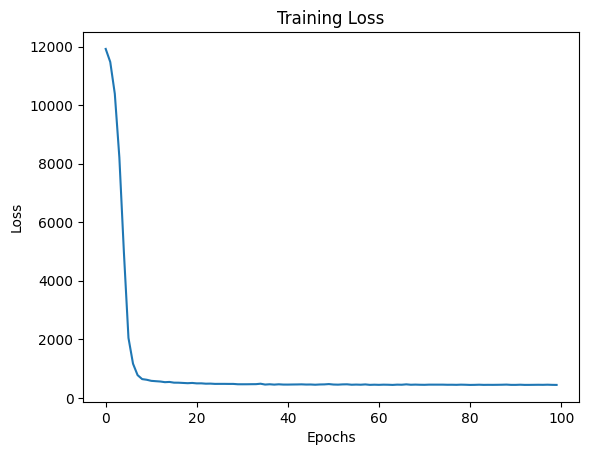

In [64]:
plt.plot(losses)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

In [65]:
# step 16: Evaluation

In [67]:
X_test = torch.tensor(X_test, dtype=torch.float32)

model.eval()

with torch.no_grad():

    predictions = model(X_test)

    test_loss = criterion(predictions, y_test)

print("Test Loss:", test_loss.item())

Test Loss: 53.61430358886719


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([40])) that is different to the input size (torch.Size([40, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [ ]:
# Prediciton

In [70]:

new_student = np.array([[7, 8, 90, 75]])

new_student = scaler.transform(new_student)

new_student = torch.tensor(
    new_student,
    dtype=torch.float32
)

model.eval()

with torch.no_grad():

    predicted_score = model(new_student)

print("Predicted Exam Score:", predicted_score.item())

Predicted Exam Score: 34.616294860839844


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
